In [1]:
# Install required packages
!pip install -q kaggle
!pip install -q opencv-python

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"iamshahidkamal","key":"687c7f503fa3d03333a0726c2d2a53cc"}'}

In [3]:
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d msambare/fer2013
!unzip -q fer2013.zip -d fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import torch, cv2
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CLAHETransform:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __call__(self, img):
        img_np = np.array(img)
        if len(img_np.shape) == 3:
            img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        img_clahe = self.clahe.apply(img_np)
        return Image.fromarray(img_clahe)

transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [9]:
train_dataset = ImageFolder(root="/content/fer2013/train", transform=transform)
test_dataset = ImageFolder(root="/content/fer2013/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [10]:
"""
class EmotionCNN(nn.Module):
    def __init__(self):
        super(EmotionCNN, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, 7)

    def forward(self, x):
        x = self.conv1(x)  # 48 → 24
        x = self.conv2(x)  # 24 → 12
        x = self.conv3(x)  # 12 → 6
        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, 7)

    def forward(self, x):
        x = self.conv1(x)  # 48 → 24
        x = self.conv2(x)  # 24 → 12
        x = self.conv3(x)  # 12 → 6
        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

"""

'\nclass EmotionCNN(nn.Module):\n    def __init__(self):\n        super(EmotionCNN, self).__init__()\n\n        self.conv1 = nn.Sequential(\n            nn.Conv2d(1, 32, kernel_size=3, padding=1),\n            nn.BatchNorm2d(32),\n            nn.ReLU(),\n            nn.MaxPool2d(2),\n            nn.Dropout(0.2)\n        )\n\n        self.conv2 = nn.Sequential(\n            nn.Conv2d(32, 64, kernel_size=3, padding=1),\n            nn.BatchNorm2d(64),\n            nn.ReLU(),\n            nn.MaxPool2d(2),\n            nn.Dropout(0.2)\n        )\n\n        self.conv3 = nn.Sequential(\n            nn.Conv2d(64, 128, kernel_size=3, padding=1),\n            nn.BatchNorm2d(128),\n            nn.ReLU(),\n            nn.MaxPool2d(2)\n            \n        )\n\n        self.dropout = nn.Dropout(0.25)\n        self.fc1 = nn.Linear(128 * 6 * 6, 256)\n        self.fc2 = nn.Linear(256, 7)\n\n    def forward(self, x):\n        x = self.conv1(x)  # 48 → 24\n        x = self.conv2(x)  # 24 → 12\n       

In [14]:
"""
from torchvision.models import resnet18
import torch.nn as nn

model = resnet18(pretrained=True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # 1-channel input
model.fc = nn.Linear(512, 7)
"""
from torchvision.models import resnet18
import torch.nn as nn

model_resnet = resnet18(pretrained=True)
model_resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # For grayscale input
model_resnet.fc = nn.Linear(512, 7)  # 7 emotion classes

# Optional: Freeze layers initially
for param in model_resnet.parameters():
    param.requires_grad = False

# Unfreeze last few blocks
for param in model_resnet.layer4.parameters():
    param.requires_grad = True
for param in model_resnet.fc.parameters():
    param.requires_grad = True

model = model_resnet.to(device)

In [15]:
def train(model, train_loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

In [16]:
#model = EmotionCNN().to(device)

model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
train_losses = []
test_accuracies = []

for epoch in range(25):
    loss = train(model, train_loader, criterion, optimizer)
    scheduler.step()
    acc = evaluate(model, test_loader)

    train_losses.append(loss)

    test_accuracies.append(acc)

    print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Accuracy: {acc:.2f}%")

Epoch 1 | Loss: 1.8227 | Accuracy: 31.03%
Epoch 2 | Loss: 1.7397 | Accuracy: 34.45%
Epoch 3 | Loss: 1.7150 | Accuracy: 35.44%
Epoch 4 | Loss: 1.7005 | Accuracy: 36.14%
Epoch 5 | Loss: 1.6854 | Accuracy: 37.06%
Epoch 6 | Loss: 1.6719 | Accuracy: 37.31%
Epoch 7 | Loss: 1.6607 | Accuracy: 37.14%
Epoch 8 | Loss: 1.6513 | Accuracy: 39.11%
Epoch 9 | Loss: 1.6467 | Accuracy: 38.16%
Epoch 10 | Loss: 1.6339 | Accuracy: 37.82%
Epoch 11 | Loss: 1.6002 | Accuracy: 38.79%
Epoch 12 | Loss: 1.5875 | Accuracy: 40.03%
Epoch 13 | Loss: 1.5742 | Accuracy: 40.42%
Epoch 14 | Loss: 1.5658 | Accuracy: 38.85%
Epoch 15 | Loss: 1.5563 | Accuracy: 41.29%
Epoch 16 | Loss: 1.5474 | Accuracy: 41.20%
Epoch 17 | Loss: 1.5343 | Accuracy: 40.99%
Epoch 18 | Loss: 1.5259 | Accuracy: 41.18%
Epoch 19 | Loss: 1.5180 | Accuracy: 41.45%
Epoch 20 | Loss: 1.5067 | Accuracy: 40.61%
Epoch 21 | Loss: 1.4727 | Accuracy: 41.84%
Epoch 22 | Loss: 1.4574 | Accuracy: 40.53%
Epoch 23 | Loss: 1.4426 | Accuracy: 41.91%
Epoch 24 | Loss: 1.4

In [17]:
emotion_classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

def predict_and_plot(model, image_path, transform):
    img = Image.open(image_path).convert('L')
    img_t = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(img_t)
        probs = torch.softmax(output, dim=1).cpu().numpy().flatten()
        top3_idx = probs.argsort()[-3:][::-1]

    # Display image
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    # Show top 3 predictions
    top_labels = [f"{emotion_classes[i]} ({probs[i]*100:.1f}%)" for i in top3_idx]
    plt.title("Top 3 Predictions:\n" + "\n".join(top_labels))
    plt.show()


Saving istockphoto-1399611777-612x612.jpg to istockphoto-1399611777-612x612.jpg


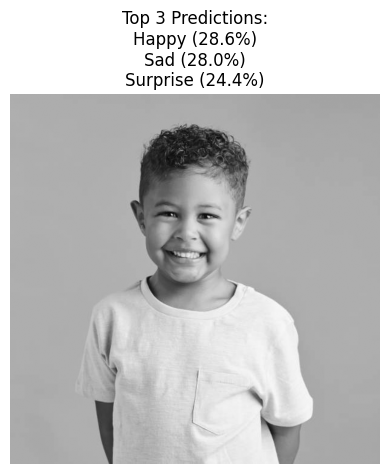

In [18]:
from google.colab import files
uploaded = files.upload()

# Use any uploaded image
image_path = list(uploaded.keys())[0]
predict_and_plot(model, image_path, transform)

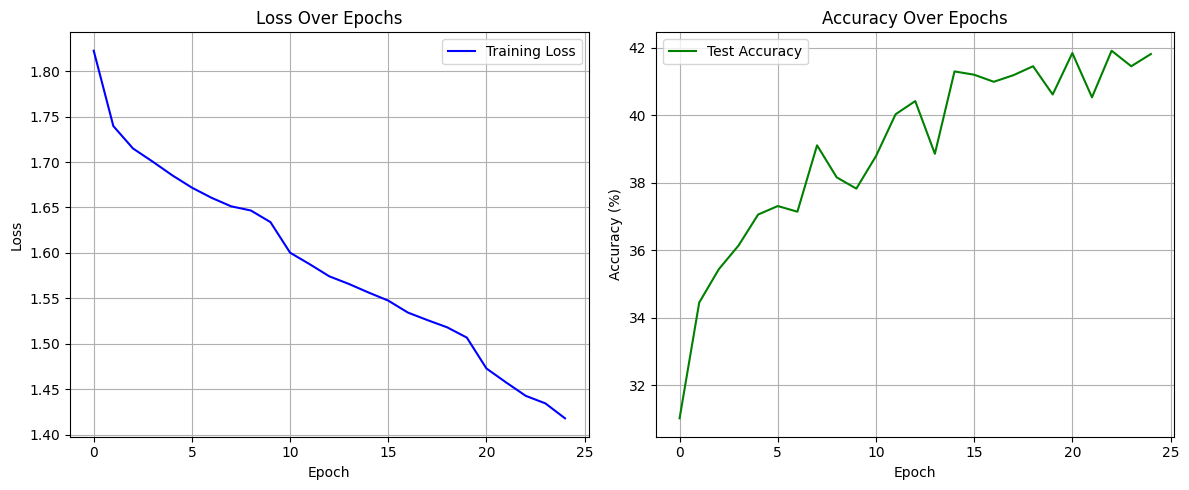

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Training Loss", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.grid(True)
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label="Test Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Over Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

<Figure size 800x800 with 0 Axes>

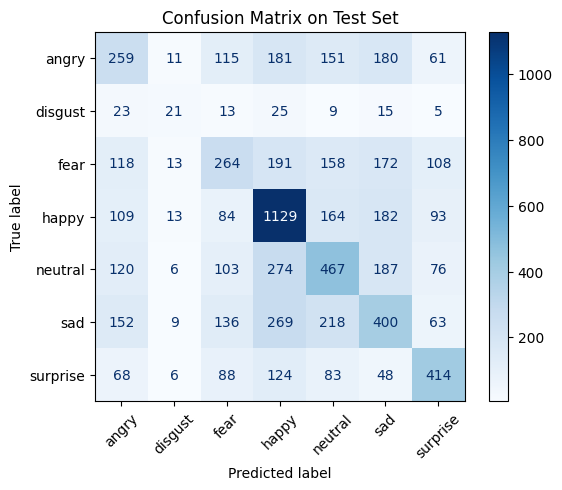

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_all_preds(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

# Get predictions and true labels
y_pred, y_true = get_all_preds(model, test_loader)

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)

plt.figure(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.grid(False)
plt.show()

In [21]:
from sklearn.metrics import classification_report

y_pred, y_true = get_all_preds(model, test_loader)
print(classification_report(y_true, y_pred, target_names=test_dataset.classes))

              precision    recall  f1-score   support

       angry       0.31      0.29      0.30       958
     disgust       0.27      0.24      0.26       111
        fear       0.31      0.24      0.27      1024
       happy       0.50      0.64      0.56      1774
     neutral       0.37      0.38      0.38      1233
         sad       0.35      0.31      0.33      1247
    surprise       0.50      0.48      0.49       831

    accuracy                           0.41      7178
   macro avg       0.37      0.37      0.37      7178
weighted avg       0.40      0.41      0.40      7178



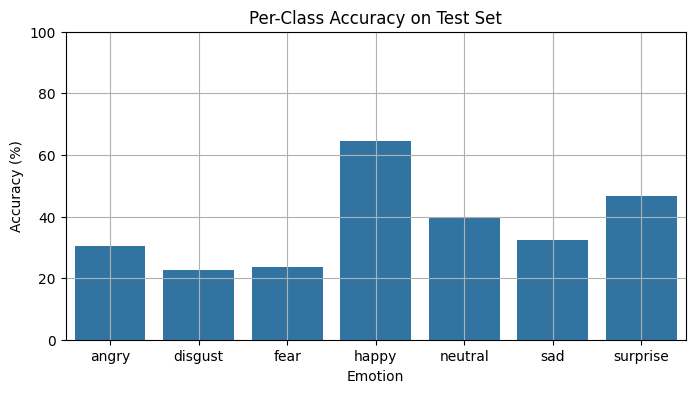

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

num_classes = len(test_dataset.classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (preds[i] == label).item()
            class_total[label] += 1

# Bar Plot
acc_per_class = [100 * c / t for c, t in zip(class_correct, class_total)]
plt.figure(figsize=(8,4))
sns.barplot(x=test_dataset.classes, y=acc_per_class)
plt.title("Per-Class Accuracy on Test Set")
plt.ylabel("Accuracy (%)")
plt.xlabel("Emotion")
plt.ylim(0, 100)
plt.grid(True)
plt.show()